/tmp/ipykernel_1821581/375726061.py:140: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(ckpt_path, map_location="cpu")


Computed models:
step4_qat_int4                                | arch=resnet18_depthwise | acc=84.23% | score=0.012675 | q=(4.00,4.00) | amount_s=0.70, amount_u=0.70
step4_qat_mixed_tau_1                         | arch=resnet18_depthwise | acc=90.97% | score=0.019527 | q=(6.16,6.16) | amount_s=0.70, amount_u=0.70
step4_qat_mixed_tau_0p5                       | arch=resnet18_depthwise | acc=91.16% | score=0.021240 | q=(6.70,6.70) | amount_s=0.70, amount_u=0.70
step4_qat_int8                                | arch=resnet18_depthwise | acc=91.55% | score=0.025351 | q=(8.00,8.00) | amount_s=0.70, amount_u=0.70
legacy_struct0p7_unstruct0p7_int4_qat         | arch=resnet18           | acc=90.10% | score=0.096835 | q=(4.00,4.00) | amount_s=0.70, amount_u=0.70
step3_unstructured_finetuned                  | arch=resnet18_depthwise | acc=91.38% | score=0.101404 | q=(32.00,32.00) | amount_s=0.70, amount_u=0.70
step2_structured_finetuned                    | arch=resnet18_depthwise | acc=90.62% | 

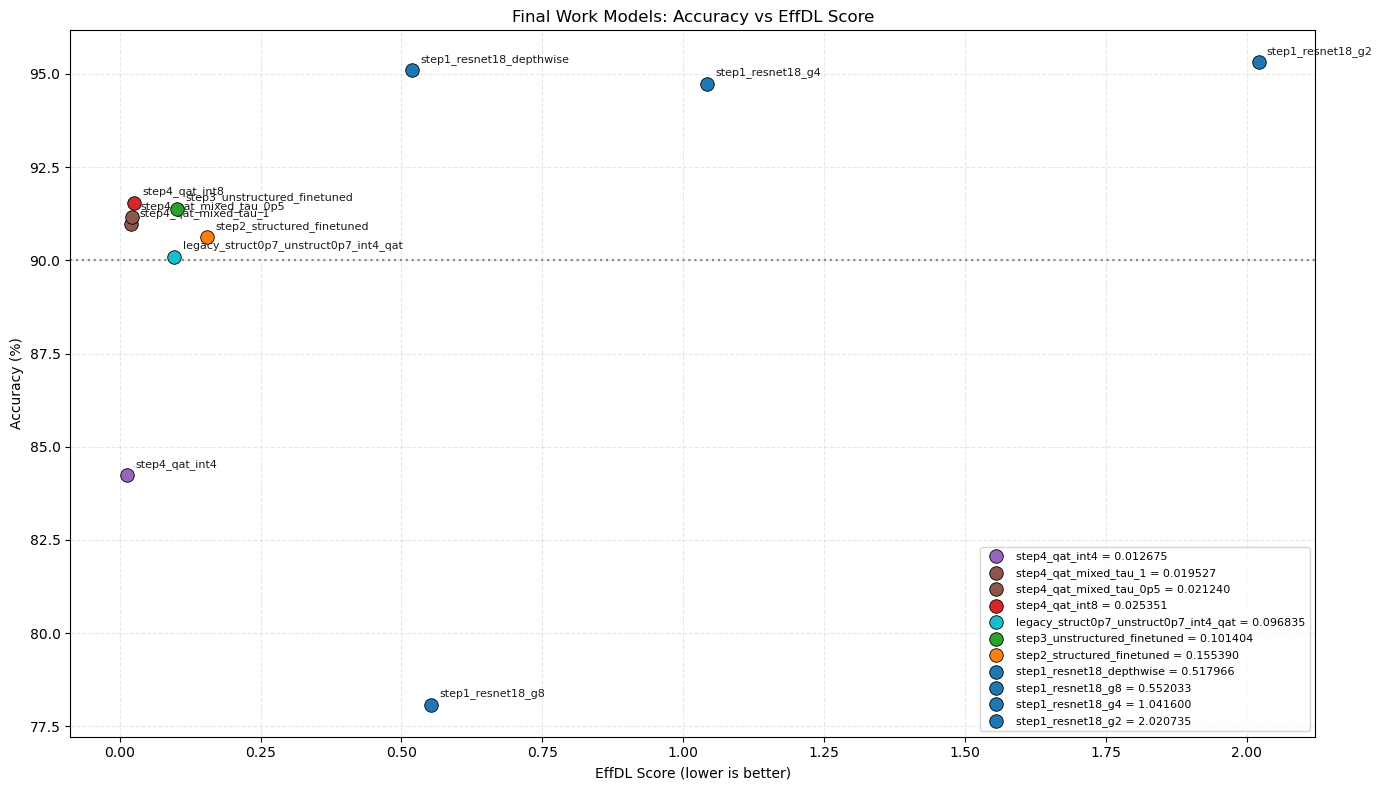

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from models import (
    ResNet18,
    ResNet18_Depthwise,
    ResNet18_GroupedG2,
    ResNet18_GroupedG4,
    ResNet18_GroupedG8,
)


# -----------------------------
# 1) Score formula (your setup)
# -----------------------------
def compute_pruning_ratios_from_amounts(amount_s, amount_u):
    if not (0.0 <= amount_s <= 1.0 and 0.0 <= amount_u <= 1.0):
        raise ValueError("amount_s and amount_u must be in [0, 1].")
    p_s = float(amount_s)
    p_u = (1.0 - p_s) * float(amount_u)
    return p_s, p_u


def compute_effdl_score(amount_s, amount_u, q_w, q_a, w, f, ref_params=5.6e6, ref_ops=2.8e8):
    p_s, p_u = compute_pruning_ratios_from_amounts(amount_s, amount_u)

    if min(q_w, q_a, w, f) < 0:
        raise ValueError("q_w, q_a, w and f must be non-negative.")

    params_term = (1.0 - (p_s + p_u)) * ((q_w / 32.0) * w) / ref_params
    ops_term = (1.0 - p_s) * (max(q_w, q_a) / 32.0) * f / ref_ops
    return params_term + ops_term


# ------------------------------------------
# 2) Architecture -> model, w (#params), f (ops)
# ------------------------------------------
MODEL_BUILDERS = {
    "resnet18": ResNet18,
    "resnet18_depthwise": ResNet18_Depthwise,
    "resnet18_g2": ResNet18_GroupedG2,
    "resnet18_g4": ResNet18_GroupedG4,
    "resnet18_g8": ResNet18_GroupedG8,
}


def infer_arch_from_name(name: str):
    n = name.lower()
    if "depthwise" in n:
        return "resnet18_depthwise"
    if "_g2" in n or "groupedg2" in n:
        return "resnet18_g2"
    if "_g4" in n or "groupedg4" in n:
        return "resnet18_g4"
    if "_g8" in n or "groupedg8" in n:
        return "resnet18_g8"
    return "resnet18"


def count_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters())


def count_ops_single_forward(model: nn.Module, input_shape=(1, 3, 32, 32)):
    """
    Rough MAC-like op count for Conv2d + Linear on CIFAR-10 input.
    """
    model.eval()
    total_ops = 0
    hooks = []

    def conv_hook(module, inp, out):
        nonlocal total_ops
        # inp[0]: [N, Cin, Hin, Win], out: [N, Cout, Hout, Wout]
        out_tensor = out if isinstance(out, torch.Tensor) else out[0]
        n, cout, hout, wout = out_tensor.shape
        cin = module.in_channels
        kh, kw = module.kernel_size
        groups = module.groups
        # Per output element MACs = Cin/groups * Kh * Kw
        ops_per_out = (cin // groups) * kh * kw
        total_ops += n * cout * hout * wout * ops_per_out

    def linear_hook(module, inp, out):
        nonlocal total_ops
        out_tensor = out if isinstance(out, torch.Tensor) else out[0]
        n = out_tensor.shape[0]
        total_ops += n * module.in_features * module.out_features

    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            hooks.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook))

    with torch.no_grad():
        x = torch.randn(*input_shape)
        model(x)

    for h in hooks:
        h.remove()

    return int(total_ops)


# Cache architecture costs once
arch_costs = {}
for arch_name, builder in MODEL_BUILDERS.items():
    m = builder()
    arch_costs[arch_name] = {
        "w": float(count_params(m)),
        "f": float(count_ops_single_forward(m)),
    }


# -------------------------------------------------
# 3) Load all tested Final Work models and metadata
# -------------------------------------------------
ROOT = Path.cwd()
STEP1_DIR = ROOT / "Final Weights" / "step1"
STEP2_JSON = ROOT / "Final Weights" / "step2" / "structured_pruning_distilled_results.json"
STEP3_JSON = ROOT / "Final Weights" / "step3" / "unstructured_pruning_results.json"
STEP4_QAT4_JSON = ROOT / "Final Weights" / "step4" / "qat_4bit_results_84_accuracy.json"
STEP4_QAT8_JSON = ROOT / "Final Weights" / "step4" / "qat_8bit_results.json"
STEP4_MIXED_DIR = ROOT / "Final Weights" / "step4"

# Explicit extra model requested by path
EXTRA_QAT4_PTH = ROOT / "Models Weights" / "quantization" / "unstructured_pruning_qat_4bit" / "Resnet18_unstructured_pruned_70_basemodel_0.7structured_augmix_30ep_int4_qat.pth"
EXTRA_QAT4_RESULTS_JSON = ROOT / "quantization" / "unstructured_pruning_qat_4bit_results.json"
EXTRA_QAT4_BASE_NAME = "Resnet18_unstructured_pruned_70_basemodel_0.7structured_augmix_30ep.pth"

records = []

# Stage 1: distilled checkpoints (no pruning, FP32)
for ckpt_path in sorted(STEP1_DIR.glob("*.pth")):
    obj = torch.load(ckpt_path, map_location="cpu")
    acc = obj.get("acc", obj.get("best_acc"))
    if acc is None:
        continue
    arch = infer_arch_from_name(ckpt_path.stem)
    records.append(
        {
            "label": f"step1_{ckpt_path.stem}",
            "stage": "step1_distilled",
            "arch": arch,
            "accuracy": float(acc),
            "amount_s": 0.0,
            "amount_u": 0.0,
            "q_w": 32.0,
            "q_a": 32.0,
        }
    )

# Stage 2: structured pruning + finetune (FP32)
if STEP2_JSON.exists():
    d2 = json.loads(STEP2_JSON.read_text(encoding="utf-8"))
    run2 = d2["runs"][0]
    records.append(
        {
            "label": "step2_structured_finetuned",
            "stage": "step2_structured",
            "arch": d2.get("model_arch", "resnet18_depthwise"),
            "accuracy": float(run2["accuracy_after_finetune"]),
            "amount_s": float(run2["amount"]),
            "amount_u": 0.0,
            "q_w": 32.0,
            "q_a": 32.0,
        }
    )

# Stage 3: structured + unstructured + finetune (FP32)
if STEP3_JSON.exists():
    d3 = json.loads(STEP3_JSON.read_text(encoding="utf-8"))
    run3 = d3["runs"][0]
    amount_s_step2 = 0.7
    if STEP2_JSON.exists():
        d2 = json.loads(STEP2_JSON.read_text(encoding="utf-8"))
        amount_s_step2 = float(d2["runs"][0]["amount"])

    records.append(
        {
            "label": "step3_unstructured_finetuned",
            "stage": "step3_unstructured",
            "arch": d3.get("model_arch", "resnet18_depthwise"),
            "accuracy": float(run3["accuracy_after_finetune"]),
            "amount_s": amount_s_step2,
            "amount_u": float(run3["amount"]),
            "q_w": 32.0,
            "q_a": 32.0,
        }
    )

# Stage 4: 4-bit QAT
if STEP4_QAT4_JSON.exists():
    d4 = json.loads(STEP4_QAT4_JSON.read_text(encoding="utf-8"))
    records.append(
        {
            "label": "step4_qat_int4",
            "stage": "step4_qat4",
            "arch": d4.get("model_arch", "resnet18_depthwise"),
            "accuracy": float(d4["int4_final_test_acc"]),
            "amount_s": 0.7,
            "amount_u": 0.7,
            "q_w": 4.0,
            "q_a": 4.0,
        }
    )

# Stage 4: 8-bit QAT
if STEP4_QAT8_JSON.exists():
    d8 = json.loads(STEP4_QAT8_JSON.read_text(encoding="utf-8"))
    records.append(
        {
            "label": "step4_qat_int8",
            "stage": "step4_qat8",
            "arch": d8.get("model_arch", "resnet18_depthwise"),
            "accuracy": float(d8["int8_final_test_acc"]),
            "amount_s": 0.7,
            "amount_u": 0.7,
            "q_w": 8.0,
            "q_a": 8.0,
        }
    )

# Stage 4: mixed precision QAT (load all taus)
mixed_paths = sorted(STEP4_MIXED_DIR.glob("qat_mixed_precision_results*.json"))
seen_mixed_labels = set()
for mixed_json_path in mixed_paths:
    dm = json.loads(mixed_json_path.read_text(encoding="utf-8"))
    tau_val = dm.get("sensitivity_threshold", "na")
    tau_text = str(tau_val).replace(".", "p")
    label = f"step4_qat_mixed_tau_{tau_text}"
    if label in seen_mixed_labels:
        continue
    seen_mixed_labels.add(label)

    q_eff = float(dm.get("bit_summary", {}).get("effective_qw", 8.0))
    records.append(
        {
            "label": label,
            "stage": "step4_qat_mixed",
            "arch": dm.get("model_arch", "resnet18_depthwise"),
            "accuracy": float(dm["mixed_final_test_acc"]),
            "amount_s": 0.7,
            "amount_u": 0.7,
            "q_w": q_eff,
            "q_a": q_eff,
        }
    )

# Explicitly add requested legacy model from Models Weights path
if EXTRA_QAT4_PTH.exists() and EXTRA_QAT4_RESULTS_JSON.exists():
    results = json.loads(EXTRA_QAT4_RESULTS_JSON.read_text(encoding="utf-8"))
    matched = next((x for x in results if x.get("checkpoint") == EXTRA_QAT4_BASE_NAME), None)
    if matched is not None:
        records.append(
            {
                "label": "legacy_struct0p7_unstruct0p7_int4_qat",
                "stage": "legacy_qat4_sweep",
                "arch": "resnet18",
                "accuracy": float(matched["int4_test_acc"]),
                "amount_s": 0.7,
                "amount_u": 0.7,
                "q_w": 4.0,
                "q_a": 4.0,
            }
        )


# ---------------------------------
# 4) Compute w, f, score per record
# ---------------------------------
for r in records:
    arch = r["arch"]
    if arch not in arch_costs:
        raise ValueError(f"Unknown architecture '{arch}' in record '{r['label']}'")

    r["w"] = arch_costs[arch]["w"]
    r["f"] = arch_costs[arch]["f"]
    r["score"] = compute_effdl_score(
        amount_s=r["amount_s"],
        amount_u=r["amount_u"],
        q_w=r["q_w"],
        q_a=r["q_a"],
        w=r["w"],
        f=r["f"],
    )

# Sort by score (best/smallest first)
records = sorted(records, key=lambda x: x["score"])

print("Computed models:")
for r in records:
    print(
        f"{r['label']:<45} | arch={r['arch']:<18} | "
        f"acc={r['accuracy']:.2f}% | score={r['score']:.6f} | "
        f"q=({r['q_w']:.2f},{r['q_a']:.2f}) | "
        f"amount_s={r['amount_s']:.2f}, amount_u={r['amount_u']:.2f}"
    )


# -----------------------------
# 5) Scatter: x=score, y=acc
# -----------------------------
plt.figure(figsize=(14, 8))

stage_colors = {
    "step1_distilled": "#1f77b4",
    "step2_structured": "#ff7f0e",
    "step3_unstructured": "#2ca02c",
    "step4_qat8": "#d62728",
    "step4_qat4": "#9467bd",
    "step4_qat_mixed": "#8c564b",
    "legacy_qat4_sweep": "#17becf",
}

for r in records:
    x = r["score"]
    y = r["accuracy"]
    c = stage_colors.get(r["stage"], "black")
    plt.scatter(x, y, s=95, c=c, edgecolors="black", linewidths=0.6, zorder=3)
    plt.annotate(
        r["label"],
        xy=(x, y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9,
    )

# Legend entries per model with score shown beside label
for r in records:
    legend_text = f"{r['label']} = {r['score']:.6f}"
    plt.scatter(
        [],
        [],
        c=stage_colors.get(r["stage"], "black"),
        s=95,
        edgecolors="black",
        linewidths=0.6,
        label=legend_text,
    )

plt.axhline(y=90.0, color="gray", linestyle=":", linewidth=1.6, alpha=0.9)
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlabel("EffDL Score (lower is better)")
plt.ylabel("Accuracy (%)")
plt.title("Final Work Models: Accuracy vs EffDL Score")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()
